In [29]:
import numpy as np
import matplotlib.pyplot as plt
from bisect import bisect_left
from typing import Optional, List, Dict, Any
bias=True
MULT=1

# ---------- Genome helpers (same idea as before) ----------

def random_genome_int(genome_length: int, rng: np.random.Generator) -> int:
    """Random bitstring of given length as an int."""
    if genome_length > 62:
        raise ValueError("genome_length > 62: consider a different representation.")
    max_val = 1 << genome_length
    return int(rng.integers(0, max_val, endpoint=False))


def genome_int_to_str(g: int, genome_length: int) -> str:
    return format(g, f"0{genome_length}b")


# ---------- Selection weight ----------

def fitness_to_weight(f: float, beta: float = 1.0) -> float:
    """Softmax-like mapping from fitness to positive selection weight."""
    return float(np.exp(beta * f))


# ---------- Child fitness with optional bias toward 1s ----------

def sample_child_fitness(
    parent_genome: int,
    child_genome: int,
    parent_fit: float,
    sigma: float,
    bias: bool,
    rng: np.random.Generator,
) -> float:
    """
    Sample child fitness.

    If bias == False:
        child_fitness ~ N(parent_fit, sigma^2)

    If bias == True:
        child_fitness ~ N(((1 + (#1_child / #1_parent)) * parent_fit), sigma^2)

    We handle #1_parent == 0 reasonably to avoid division by zero.
    """
    if not bias:
        mean = parent_fit
    else:
        parent_ones = parent_genome.bit_count()
        child_ones = child_genome.bit_count()

        if parent_ones == 0:
            # If the parent has no 1s, define a simple rule:
            # - if child now has at least one '1', treat ratio as 1
            # - otherwise 0
            ratio = 1.0 if child_ones > 0 else 0.0
        else:
            ratio = child_ones / parent_ones

        mean = (1.0 + MULT * ratio) * parent_fit

    return float(rng.normal(loc=mean, scale=sigma))


# ---------- Main simulation ----------

def simulate_evolving_bitstrings(
    genome_length: int = 32,
    total_individuals: int = 1_000_000,
    sigma: float = 0.0005,
    beta: float = 0,
    start_random: bool = False,
    initial_fitness: float = 0.0,
    bias: bool = False,        # <--- BIAS toggle here
    seed: Optional[int] = None,
) -> Dict[str, Any]:
    """
    Simulate an ever-growing population of bit strings.

    - Start from a single ancestor.
    - At each step:
        - pick a parent with probability ∝ exp(beta * fitness)
        - copy its genome, flip one random bit
        - assign child fitness:
            * without bias:  N(parent_fit, sigma^2)
            * with bias:     N(((1 + (#1_child / #1_parent)) * parent_fit), sigma^2)
    """
    rng = np.random.default_rng(seed)

    # ----- Initialize first individual -----
    if start_random:
        root_genome = random_genome_int(genome_length, rng)
    else:
        root_genome = 0  # all zeros

    genomes: List[int] = [root_genome]
    fitnesses: List[float] = [float(initial_fitness)]
    parents: List[Optional[int]] = [None]
    generations: List[int] = [0]

    # Selection weights and cumulative sums
    w0 = fitness_to_weight(initial_fitness, beta=beta)
    weights: List[float] = [w0]
    prefix_sums: List[float] = [w0]

    # ----- Main simulation loop -----
    for i in range(1, total_individuals):
        total_weight = prefix_sums[-1]
        r = rng.random() * total_weight
        parent_idx = bisect_left(prefix_sums, r)

        parent_genome = genomes[parent_idx]
        parent_fit = fitnesses[parent_idx]
        parent_gen = generations[parent_idx]

        # Flip one random bit in the genome
        bit_to_flip = int(rng.integers(0, genome_length))
        child_genome = parent_genome ^ (1 << bit_to_flip)

        # Child fitness, with/without bias
        child_fitness = sample_child_fitness(
            parent_genome=parent_genome,
            child_genome=child_genome,
            parent_fit=parent_fit,
            sigma=sigma,
            bias=bias,
            rng=rng,
        )

        # Append child
        genomes.append(child_genome)
        fitnesses.append(child_fitness)
        parents.append(parent_idx)
        generations.append(parent_gen + 1)

        # Update weights & prefix sums
        w = fitness_to_weight(child_fitness, beta=beta)
        weights.append(w)
        prefix_sums.append(prefix_sums[-1] + w)

    return {
        "genomes": genomes,
        "fitnesses": np.array(fitnesses, dtype=float),
        "parents": parents,
        "generations": np.array(generations, dtype=int),
        "genome_length": genome_length,
    }


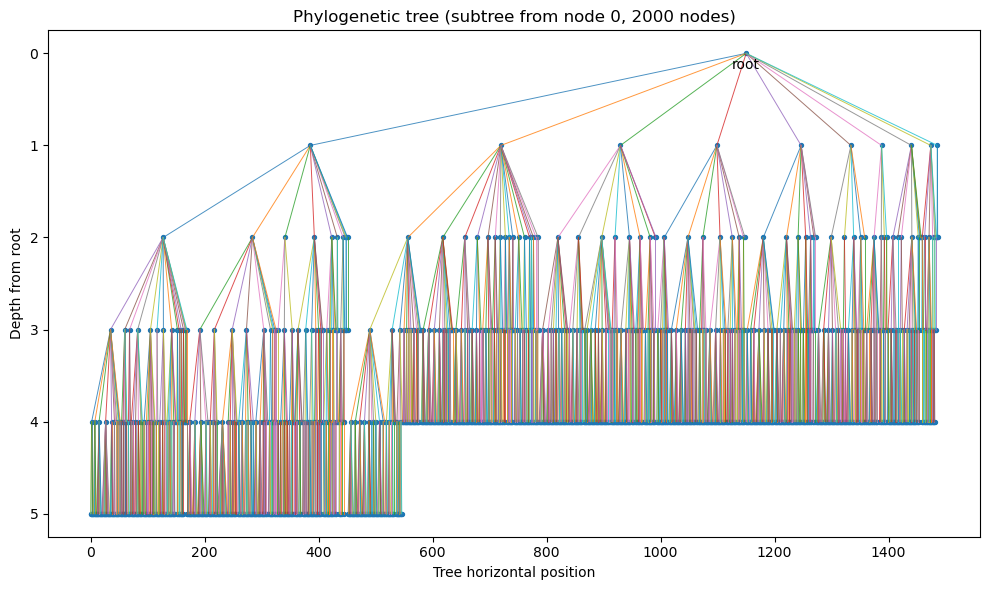

/var/folders/dg/j3xfsm6j68s_0jk_l6mqmh_h0000gn/T/ipykernel_53210/3950723020.py:26: RuntimeWarning: overflow encountered in exp
  return float(np.exp(beta * f))


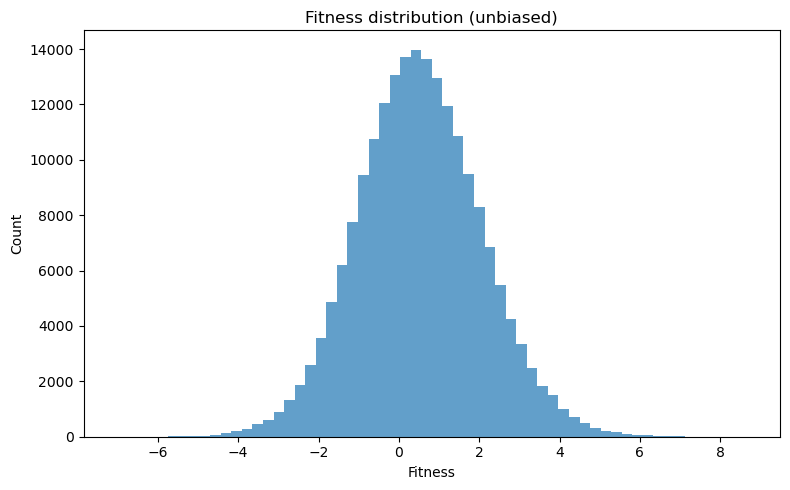

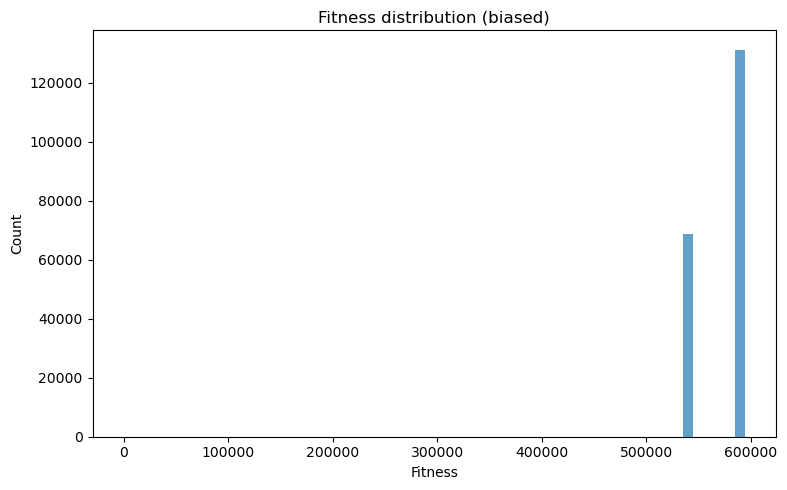

Root children: [1, 15, 16, 25, 129, 183, 1005, 1290, 1767, 2488, 14420, 15316, 18930, 43201, 123585]
Number of root children: 15


In [30]:
import matplotlib.pyplot as plt
from collections import deque
from typing import Set, Dict, List, Optional, Tuple


# ---------- Build children lists from parents ----------

def build_children_list(parents: List[Optional[int]]) -> List[List[int]]:
    """
    Given a parents list where parents[i] is the index of i's parent (or None for root),
    return a list of children: children[i] is a list of indices whose parent is i.
    """
    n = len(parents)
    children: List[List[int]] = [[] for _ in range(n)]
    for child_idx, p in enumerate(parents):
        if p is not None:
            children[p].append(child_idx)
    return children


# ---------- Extract a subtree for plotting ----------

def extract_subtree_bfs(
    children: List[List[int]],
    root_idx: int = 0,
    max_nodes: int = 2000,
    max_depth: Optional[int] = None,
) -> Set[int]:
    """
    Extract a connected subtree rooted at root_idx using BFS, limited by:
      - max_nodes: maximum number of nodes in the subtree
      - max_depth: maximum depth (0 = root only, 1 = root+children, etc.) from root

    Returns the set of node indices in that subtree.
    """
    selected: Set[int] = set()
    queue = deque()
    queue.append((root_idx, 0))

    while queue and len(selected) < max_nodes:
        node, depth = queue.popleft()
        if node in selected:
            continue
        selected.add(node)

        if max_depth is not None and depth >= max_depth:
            continue  # don't go deeper from here

        for ch in children[node]:
            if len(selected) + len(queue) >= max_nodes:
                break
            queue.append((ch, depth + 1))

    return selected


# ---------- Tree layout (simple tidy layout) ----------

def compute_tree_layout(
    tree_children: Dict[int, List[int]],
    root_idx: int,
) -> Tuple[Dict[int, float], Dict[int, float]]:
    """
    Assign x, y coordinates to each node in the subtree using a simple tidy-tree style.

    - x: horizontal order across leaves
    - y: depth (0 for root, increasing for descendants; you can invert in plot)

    tree_children: dict mapping node -> list of its children IN THE SUBTREE.
    """
    x: Dict[int, float] = {}
    y: Dict[int, float] = {}
    next_x = 0

    def dfs(node: int, depth: int) -> None:
        nonlocal next_x
        kids = tree_children.get(node, [])
        if not kids:
            # Leaf: assign next x and advance
            x[node] = float(next_x)
            y[node] = float(depth)
            next_x += 1
        else:
            child_xs = []
            for ch in kids:
                dfs(ch, depth + 1)
                child_xs.append(x[ch])
            # Parent at mean of children x positions
            x[node] = sum(child_xs) / len(child_xs)
            y[node] = float(depth)

    dfs(root_idx, 0)
    return x, y


# ---------- Plotting function ----------

def plot_phylogenetic_tree(
    parents: List[Optional[int]],
    generations: Optional[np.ndarray] = None,
    root_idx: int = 0,
    max_nodes: int = 2000,
    max_depth: Optional[int] = None,
    node_size: float = 10.0,
    show_nodes: bool = True,
    annotate_root: bool = True,
) -> None:
    """
    Plot a phylogenetic tree from `root_idx` down using a subset of nodes.

    Parameters
    ----------
    parents : list of int or None
        parents[i] = index of parent of i; None for root.
    generations : np.ndarray or None
        Optional; only used for information/consistency. Not required for layout.
    root_idx : int
        Index of the root of the plotted subtree (usually 0 for original ancestor).
    max_nodes : int
        Upper bound on number of nodes in the plotted subtree.
        For very large simulations, keep this small (1k–10k) or the plot will be huge.
    max_depth : int or None
        Limit depth relative to root. If None, depth is unconstrained.
    node_size : float
        Marker size for plotting nodes.
    show_nodes : bool
        Whether to scatter-plot the nodes themselves.
    annotate_root : bool
        Whether to put a label on the root node in the plot.
    """
    # 1. Build full children list
    children = build_children_list(parents)

    # 2. Extract a subtree rooted at root_idx
    selected = extract_subtree_bfs(
        children, root_idx=root_idx, max_nodes=max_nodes, max_depth=max_depth
    )

    # 3. Restrict children to the selected subtree
    subtree_children: Dict[int, List[int]] = {
        i: [c for c in children[i] if c in selected]
        for i in selected
    }

    # 4. Compute coordinates for nodes in the subtree
    x, y = compute_tree_layout(subtree_children, root_idx=root_idx)

    # 5. Plot edges
    plt.figure(figsize=(10, 6))
    for parent, kids in subtree_children.items():
        for ch in kids:
            plt.plot(
                [x[parent], x[ch]],
                [y[parent], y[ch]],
                linewidth=0.7,
                alpha=0.8,
            )

    # 6. Plot nodes (optional)
    if show_nodes:
        xs = [x[i] for i in selected]
        ys = [y[i] for i in selected]
        plt.scatter(xs, ys, s=node_size)

    # 7. Annotations
    if annotate_root and root_idx in selected:
        plt.text(
            x[root_idx],
            y[root_idx] + 0.2,
            "root",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    plt.gca().invert_yaxis()  # so root appears at the top
    plt.xlabel("Tree horizontal position")
    plt.ylabel("Depth from root")
    plt.title(
        f"Phylogenetic tree (subtree from node {root_idx}, "
        f"{len(selected)} nodes)"
    )
    plt.tight_layout()
    # When you run this script, call plt.show() afterwards.


# ---------- Example usage with previous simulation ----------

if __name__ == "__main__":
    sim = simulate_evolving_bitstrings(
        genome_length=32,
        total_individuals=200_000,  # test smaller before cranking this up
        sigma=0.5,
        beta=0,
        start_random=False,
        initial_fitness=0.0,
        seed=123,
    )

    parents = sim["parents"]
    generations = sim["generations"]

    # Example: plot subtree from the original ancestor (index 0),
    # limited to 2000 nodes and depth 12.
    plot_phylogenetic_tree(
        parents=parents,
        generations=generations,
        root_idx=0,
        max_nodes=2000,
        max_depth=12,
        node_size=8.0,
    )

    plt.show()


def plot_fitness_distribution(sim, bins=50, label=None):
    fitnesses = sim["fitnesses"]

    plt.figure(figsize=(8, 5))
    plt.hist(fitnesses, bins=bins, alpha=0.7)
    plt.xlabel("Fitness")
    plt.ylabel("Count")
    title = "Fitness distribution"
    if label is not None:
        title += f" ({label})"
    plt.title(title)
    plt.tight_layout()
    # call plt.show() later

sim_unbiased = simulate_evolving_bitstrings(
    genome_length=32,
    total_individuals=200_000,
    sigma=0.5,
    beta=0.005,
    start_random=False,
    initial_fitness=0.1,
    bias=False,
    seed=1,
)

sim_biased = simulate_evolving_bitstrings(
    genome_length=32,
    total_individuals=200_000,
    sigma=0.5,
    beta=0.005,
    start_random=False,
    initial_fitness=0.1,
    bias=True,   # bias toward more 1s
    seed=2,
)

plot_fitness_distribution(sim_unbiased, bins=60, label="unbiased")
plot_fitness_distribution(sim_biased,   bins=60, label="biased")
plt.show()


children = build_children_list(sim_unbiased["parents"])
print("Root children:", children[0])
print("Number of root children:", len(children[0]))


/var/folders/dg/j3xfsm6j68s_0jk_l6mqmh_h0000gn/T/ipykernel_53210/1913047534.py:25: RuntimeWarning: overflow encountered in exp
  return float(np.exp(beta * f))


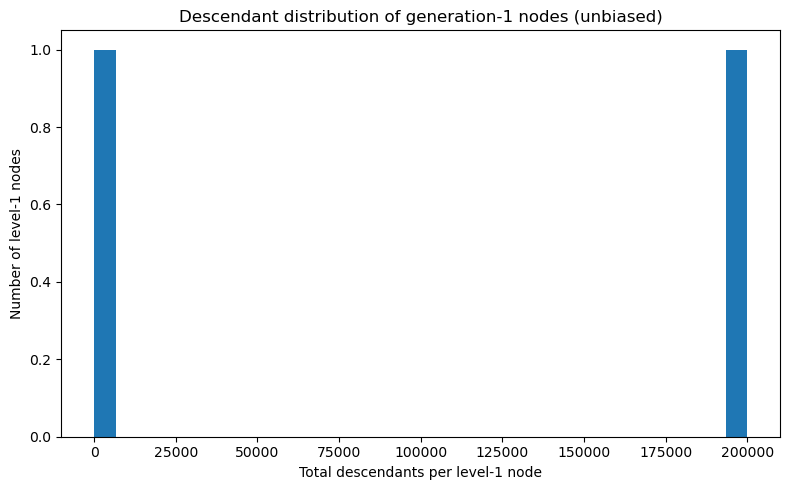

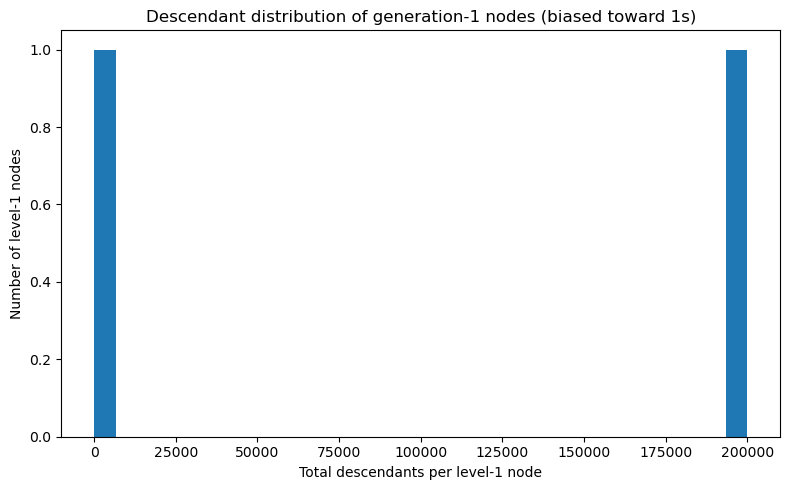

In [7]:
# ---------- Tree utilities for descendant counting ----------

def compute_subtree_sizes(parents: List[Optional[int]]) -> List[int]:
    """
    Compute size of subtree (including the node itself) for every node,
    using the fact that parents[i] < i for this simulation.

    Returns list 'sizes' where sizes[i] is the number of nodes in i's subtree.
    """
    n = len(parents)
    sizes = [1] * n  # each node counts as 1

    # Traverse nodes in reverse order; children have larger indices than parents
    for i in range(n - 1, -1, -1):
        p = parents[i]
        if p is not None:
            sizes[p] += sizes[i]
    return sizes


def level1_descendant_counts(
    parents: List[Optional[int]],
    root_idx: int = 0,
) -> List[int]:
    """
    For each generation-1 node (direct child of root_idx), compute the
    total number of descendants (children, grandchildren, etc.).
    """
    sizes = compute_subtree_sizes(parents)

    # Level-1 nodes are those whose parent is root_idx
    level1_nodes = [i for i, p in enumerate(parents) if p == root_idx]

    # Each subtree size includes the node itself, so subtract 1
    desc_counts = [sizes[i] - 1 for i in level1_nodes]
    return desc_counts


def plot_level1_descendant_hist(
    parents: List[Optional[int]],
    root_idx: int = 0,
    bins: int = 30,
    title_suffix: str = "",
) -> None:
    """
    Plot histogram of descendant counts for generation-1 nodes.
    """
    desc_counts = level1_descendant_counts(parents, root_idx=root_idx)

    plt.figure(figsize=(8, 5))
    plt.hist(desc_counts, bins=bins)
    plt.xlabel("Total descendants per level-1 node")
    plt.ylabel("Number of level-1 nodes")
    t = "Descendant distribution of generation-1 nodes"
    if title_suffix:
        t += f" ({title_suffix})"
    plt.title(t)
    plt.tight_layout()
    # Call plt.show() in your script after plotting.

if __name__ == "__main__":
    # Smaller first to test; then increase total_individuals.
    sim_unbiased = simulate_evolving_bitstrings(
        genome_length=32,
        total_individuals=200_000,
        sigma=0.5,
        beta=1.0,
        start_random=False,
        initial_fitness=0.1,   # give root some nonzero fitness
        bias=False,
        seed=1,
    )

    sim_biased = simulate_evolving_bitstrings(
        genome_length=32,
        total_individuals=200_000,
        sigma=0.5,
        beta=1.0,
        start_random=False,
        initial_fitness=0.1,
        bias=True,             # <--- bias toward 1s
        seed=2,
    )

    # Plot histogram for each
    plot_level1_descendant_hist(
        parents=sim_unbiased["parents"],
        root_idx=0,
        bins=30,
        title_suffix="unbiased",
    )

    plot_level1_descendant_hist(
        parents=sim_biased["parents"],
        root_idx=0,
        bins=30,
        title_suffix="biased toward 1s",
    )

    plt.show()
